# Helios 01 — Vector Engine: building footprints to vector PMTiles

**Solar site-selection, step 1: the candidate surfaces.** Every rooftop in San
Francisco is a potential solar surface. This notebook pulls **Overture Maps building
footprints** for the city, encodes them into **Mapbox Vector Tiles** with
`gbx_st_asmvt`, pyramids them across zoom levels with `gbx_st_asmvt_pyramid`, folds
the whole pyramid into one **PMTiles** archive with `gbx_pmtiles_agg`, and views it
inline with `plot_pmtiles`. The result is a single self-contained vector basemap of
every candidate roof — the geometry layer the later notebooks score for solar yield.

Along the way we compose with **Databricks-native** `ST_*` and `H3` functions — GeoBrix
tiling is an on-ramp into the native spatial engine, not a replacement for it — to
quantify roof area and bin roofs into an H3 roof-density surface.

> Runs on the **lightweight tier (Serverless)** by default. See `config_nb` for the
> heavyweight switch.
---
_Last Modified:_ June 29, 2026

![Overture buildings to vector PMTiles](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/helios/helios-01.png)

In [0]:
%run ./config_nb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'geobrix' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/geobrix/data'
... HELIOS_DIR: '/Volumes/geospatial_docs/geobrix/data/helios' (MKDIRS)
... SF_CITY_BBOX: (-122.52, 37.7, -122.35, 37.83)


In [0]:
# Toggles (also overridable per-notebook in a cell right after %run ./config_nb):
FORCE_REBUILD = False      # True (default False) -> re-create tables / re-download / re-tile (skip-guards off)
INTERACTIVE_PLOTS = False  # False (default) -> fast static maps that render on GitHub; True -> interactive maps

## 1. Discover Overture building assets for the SF AOI

`OvertureClient.discover` traverses Overture's static STAC catalog and returns one
row per GeoParquet asset that intersects our bbox — metadata only, on the driver.
We narrow to the `buildings` theme; `themes=None` would select every theme.

This step (and the download in step 2) hits the network, so it is **skipped on
re-runs once the AOI is staged** in the `overture_buildings_meta` Delta table — set
`FORCE_REBUILD = True` to re-discover and re-download.

In [0]:
# Skip the network discover + download once the AOI is staged in Delta
# (overture_buildings_meta), unless FORCE_REBUILD. Re-runs then read the staged
# geometries directly in step 3 without any network access.
_overture_staged = spark.catalog.tableExists("overture_buildings_meta")
_need_overture = FORCE_REBUILD or not _overture_staged

assets = None
if not _need_overture:
    print("... overture_buildings_meta already staged (skip discover; set FORCE_REBUILD=True to refresh)")
else:
    assets = overture.discover(SF_CITY_BBOX, themes=["buildings"])
    display(assets)        # theme, type, href, asset_bbox, release
    print(f"... {assets.count()} intersecting building assets")

... overture_buildings_meta already staged (skip discover; set FORCE_REBUILD=True to refresh)


## 2. Download the AOI subset to a Volume (+ catalog it in Delta)

`OvertureClient.download` fetches just the AOI subset through the official
**`overturemaps` CLI** (`download --stac --bbox`): it first uses Overture's STAC index
to pick only the GeoParquet part-files intersecting our bbox, then pyarrow reads them
over **anonymous public S3**, using the GeoParquet `bbox` column's row-group statistics
to fetch only the intersecting row-groups (HTTP range reads) and filter to rows inside
our area — a small clip, not Overture's global building tiles. It runs **driver-side**,
which is what makes it Serverless-safe (no Spark anonymous-S3 configuration needed),
writes the GeoParquet to the Volume, and UPSERTs a metadata row into the
`overture_buildings_meta` Delta table (idempotent MERGE keyed by `theme, type, source`). The file fetch is **idempotent — re-runs
reuse the staged GeoParquet** unless `FORCE_REBUILD` is set.

In [0]:
OVERTURE_DIR = f"{HELIOS_DIR}/overture"

if not _need_overture:
    # Already staged (step 1 skipped discover) — read the catalog row, no network.
    meta = spark.table("overture_buildings_meta")
    print("... overture_buildings_meta already staged (skip download; FORCE_REBUILD=False)")
    display(meta.select("theme", "type", "source", "out_file_sz", "is_out_file_valid"))
else:
    meta = overture.download(
        assets, OVERTURE_DIR,
        bbox=SF_CITY_BBOX,
        force=FORCE_REBUILD,           # AOI bbox -> overturemaps CLI server-side pushdown (Serverless-safe)
        table="overture_buildings_meta",
        validate=True,
        partitions=64,                 # hash fan-out; Serverless-safe parallelism
    )
    display(meta.select("theme", "type", "source", "out_file_sz", "is_out_file_valid"))

... overture_buildings_meta already staged (skip download; FORCE_REBUILD=False)


theme,type,source,out_file_sz,is_out_file_valid
buildings,building,/Volumes/geospatial_docs/geobrix/data/helios/overture/buildings/building/building.parquet,36555775,true
buildings,building_part,/Volumes/geospatial_docs/geobrix/data/helios/overture/buildings/building_part/building_part.parquet,346635,true


## 3. Load the building geometries

`OvertureClient.read` loads the downloaded GeoParquet back into Spark, re-applying
the bbox AOI filter. We keep the building polygon geometry and a stable id.

In [0]:
buildings = (
    overture.read("overture_buildings_meta", theme="buildings", type="building", bbox=SF_CITY_BBOX)
            .select(F.col("id").alias("feature_id"), F.col("geometry"))
)
print(f"... {buildings.count():,} building footprints in the AOI")
# display(buildings.limit(5))
buildings.limit(1).show(vertical=True) # <- for ipynb in GitHub

... 172,809 building footprints in the AOI
-RECORD 0--------------------------
 feature_id | 32d3e9f4-e686-4f5... 
 geometry   | [01 03 00 00 00 0... 



## 3b. Quantify candidate roof space with Databricks-native ST + H3

Before tiling, we use **Databricks-native** spatial functions on the same footprints —
GeoBrix tiling composes directly with the native engine. Native `st_area` /
`st_centroid` (over `st_geomfromwkb`) give each roof's **available area** and a point
to index; native `h3_longlatash3` bins those centroids into H3 cells so we can
aggregate **roof density and total roof area per cell** — a coarse "where are the
candidate solar surfaces concentrated?" view that complements the per-building tiles.
When `INTERACTIVE_PLOTS` is on, that surface renders as an **H3 heatmap** colored by
roof count (with a colormap legend), framed on the AOI.

> **Note:** `st_area(...)` on EPSG:4326 geometry returns **square degrees** — useful
> for relative comparisons within this notebook, but not metric area. The column is
> named `roof_area_deg2` to make the unit explicit. For true m² values, reproject to a
> projected CRS or use `GEOGRAPHY`-typed geometry with Databricks ST's geographic
> semantics.

> **Requires Databricks Runtime with Photon or Databricks SQL (Pro/Serverless).** The
> cells below check for `st_geomfromwkb` at runtime and skip with a note if the native
> engine is unavailable (e.g. the plain-Spark Docker container). The tiling cells are
> unaffected.

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

In [0]:
# Native ST: parse WKB -> GEOMETRY, then area (planar in the layer CRS) + centroid.
# st_geomfromwkb bridges GeoBrix WKB output to native Databricks ST.
# st_area here is planar in EPSG:4326 (square degrees — useful for relative
# comparison; for true m² work in a projected CRS or use GEOGRAPHY/st_area semantics
# per the Databricks ST reference).
_native_st_available = False
roofs = None
try:
    roofs = buildings.selectExpr(
        "feature_id",
        "geometry",
        "st_area(st_geomfromwkb(geometry)) AS roof_area_deg2",
        "st_x(st_centroid(st_geomfromwkb(geometry))) AS lon",
        "st_y(st_centroid(st_geomfromwkb(geometry))) AS lat",
    )
    # display(roofs.orderBy(F.col("roof_area_deg2").desc()).limit(5))
    roofs.orderBy(F.col("roof_area_deg2").desc()).limit(1).show(vertical=True) # <- for ipynb in GitHub
    _native_st_available = True
except Exception as _e:
    print(f"... native ST functions unavailable ({type(_e).__name__}); skipping roof-area cell")
    print("    (st_geomfromwkb / st_area / st_centroid require Databricks Runtime with Photon or SQL Pro/Serverless)")

-RECORD 0------------------------------
 feature_id     | ccaefe26-b7c6-4bf... 
 geometry       | [01 03 00 00 00 0... 
 roof_area_deg2 | 4.576298775000087E-6 
 lon            | -122.38105675661085  
 lat            | 37.74001565357497    



In [0]:
# Native H3: index each roof centroid to an H3 cell (res 11 ~ city-block scale) and
# aggregate roof count + total area per cell -> a roof-density surface.
# h3_longlatash3(lon, lat, resolution) is the Databricks-native point->H3 built-in
# (returns BIGINT cell index; use h3_longlatash3string for the string encoding).
H3_RES = 11

if _native_st_available and roofs is not None:
    try:
        roof_density = (
            roofs.selectExpr("*", f"h3_longlatash3(lon, lat, {H3_RES}) AS h3_cell")
                 .groupBy("h3_cell")
                 .agg(F.count("*").alias("n_roofs"),
                      F.sum("roof_area_deg2").alias("total_roof_area_deg2"))
        )
        display(roof_density.orderBy(F.col("total_roof_area_deg2").desc()).limit(10))

        # Interactive companion to the per-building tiles: render the surface as an H3
        # heatmap, colored per cell by roof count via a vivid YlOrRd ramp with a colormap
        # legend. Gated on INTERACTIVE_PLOTS (static default keeps the exported ipynb
        # GitHub-light) + framed on the AOI.
        if INTERACTIVE_PLOTS:
            from databricks.labs.gbx.vizx import grid_layer, plot_interactive
            _c = [(SF_CITY_BBOX[0] + SF_CITY_BBOX[2]) / 2,
                  (SF_CITY_BBOX[1] + SF_CITY_BBOX[3]) / 2]
            plot_interactive(
                [grid_layer(roof_density, grid_system="h3", cellid_col="h3_cell",
                            column="n_roofs", cmap="YlOrRd", scale="quantile", opacity=0.75,
                            label="roofs / cell")],
                center=_c, zoom=12,
            )
    except Exception as _e:
        print(f"... h3_longlatash3 unavailable ({type(_e).__name__}); skipping H3 density cell")
        print("    (h3_longlatash3 requires Databricks Runtime with H3 built-ins)")
else:
    print("... skipping H3 roof-density (native ST unavailable or roofs DataFrame not built)")

h3_cell,n_roofs,total_roof_area_deg2
626707369099931647,1,4.576298775000087E-6
626707369219735551,18,4.048997084995612E-6
626707369259646975,1,3.0451074000056332E-6
626707369246928895,4,2.8181985249822276E-6
626707369256206335,2,2.5640077749997144E-6
626707368754327551,1,2.544687500002889E-6
626707369225895935,1,2.531244144996291E-6
626707369080479743,1,2.5117894449995942E-6
626707374279249919,1,2.410822635003799E-6
626707369246515199,3,2.287745849996176E-6


## 4. Encode + pyramid to vector tiles

`gbx_st_asmvt_pyramid` is a table-valued function (UDTF): for each feature it emits
one `(z, x, y, mvt_bytes)` row per zoom level in the requested range, binning the
geometry into the web-mercator tile grid and encoding tile-local MVT. We pick a
city-scale zoom range (z12–z16). Attributes ride along natively (here just
`feature_id`).

> **Tier note:** the light tier (Python UDTF) emits flat columns `t.z, t.x, t.y,
> t.mvt_bytes`; the heavyweight tier wraps them in a `tile` struct (`t.tile.z`,
> `t.tile.x`, `t.tile.y`, `t.tile.mvt_bytes`). The SQL below targets the light tier;
> see the [gbx_st_asmvt_pyramid](https://databrickslabs.github.io/geobrix/docs/api/vectorx-functions?tier=heavyweight#st_asmvt_pyramid) function-info docs for the heavyweight column layout.

In [0]:
# Serverless fan-out: the overturemaps CLI writes ONE parquet, so `buildings` lands in
# only a few partitions and the per-feature pyramid UDTF would run on ~3 tasks (one
# dense-area straggler). repartition(N, COLUMN) spreads features across tasks. A column
# key is REQUIRED: number-only repartition(N) is AQE-coalesced back to serial on Serverless.
buildings = buildings.repartition(64, "feature_id")
buildings.createOrReplaceTempView("sf_buildings")

# gbx_st_asmvt_pyramid (light tier — Python UDTF) signature:
#   gbx_st_asmvt_pyramid(geom_wkb, attrs, min_z, max_z [, layer_name [, extent]])
# Output columns (flat): z INTEGER, x INTEGER, y INTEGER, mvt_bytes BINARY
# Each row is one feature's contribution to one tile — multiple features that
# fall in the same (z,x,y) appear as separate rows. gbx_pmtiles_agg merges
# those per-feature MVT blobs into one multi-feature tile (features unioned per
# layer), so every building in a tile is preserved in the final archive.
mvt = spark.sql("""
    SELECT t.z, t.x, t.y, t.mvt_bytes
    FROM sf_buildings,
         LATERAL gbx_st_asmvt_pyramid(
             geometry,
             named_struct('feature_id', feature_id),
             12, 16,
             'buildings'
         ) AS t
""")

sf_mvt = finalize_delta(mvt, "sf_buildings_mvt_tiles")
print(f"... {sf_mvt.count():,} (z,x,y) MVT rows across z12-z16")

... table sf_buildings_mvt_tiles exists (skip; FORCE_REBUILD=False)
root
 |-- z: integer (nullable = true)
 |-- x: integer (nullable = true)
 |-- y: integer (nullable = true)
 |-- mvt_bytes: binary (nullable = true)

... 886,696 (z,x,y) MVT rows across z12-z16


## 5. Fold the tile pyramid into one PMTiles archive

`gbx_pmtiles_agg` is a grouped aggregate that folds a set of `(bytes, z, x, y)` tiles
into a single PMTiles v3 archive (BINARY). We aggregate the whole pyramid into one
archive and write it to the Volume.

**Producing many archives instead of one.** A single archive is ideal for a city. At regional or continental scale, group the same tiles by a coarse **shard key** — `groupBy(shard).agg(gbx_pmtiles_agg(...))` — to emit one bounded `.pmtiles` per shard, catalogued by a `mosaic.json` manifest for client-side assembly. See **Notebook 04 — Distributed Sharding & Mosaic** for that pattern.

In [0]:
TILES_DIR = f"{HELIOS_DIR}/tiles"
PMTILES_PATH = f"{TILES_DIR}/sf_buildings.pmtiles"

In [0]:
# gbx_pmtiles_agg signature: gbx_pmtiles_agg(bytes, z, x, y [, metadata_json])
# Folds all rows into one PMTiles v3 archive. When multiple features share a
# (z,x,y) tile-id, gbx_pmtiles_agg MERGES them: it decodes each MVT blob,
# unions the features per layer, and re-encodes into a single multi-feature tile.
# Combined with gbx_st_asmvt_pyramid this is the standard vector pipeline for
# dense data — every building in each tile is preserved in the final archive.
os.makedirs(TILES_DIR, exist_ok=True)   # portable + Volume-FUSE-safe (no dbutils)

# Skip-guard: fold + write the archive ONCE; reuse on re-runs unless FORCE_REBUILD.
if FORCE_REBUILD or not os.path.exists(PMTILES_PATH):
    archive_row = (
        sf_mvt.groupBy(F.lit(1).alias("_g"))
              .agg(F.expr("gbx_pmtiles_agg(mvt_bytes, z, x, y)").alias("archive"))
              .select("archive")
              .collect()[0]
    )
    # FUSE-safe sequential write from the driver (single archive, bytes in memory)
    with open(PMTILES_PATH, "wb") as f:
        f.write(archive_row["archive"])
    print(f"... wrote {PMTILES_PATH} ({os.path.getsize(PMTILES_PATH):,} bytes)")
else:
    print(f"... {PMTILES_PATH} exists (skip; FORCE_REBUILD=False)")

... /Volumes/geospatial_docs/geobrix/data/helios/tiles/sf_buildings.pmtiles exists (skip; FORCE_REBUILD=False)


## 6. View the vector PMTiles inline

`show_pmtiles(path)` prints the `pmtiles_info` header, then renders through the
`INTERACTIVE_PLOTS` toggle (set in `config_nb`): the default **False** produces a fast
static image; **True** gives an interactive
MapLibre map (the archive base64-embedded in-browser, no tile server).

The full `sf_buildings.pmtiles` is an MVT **z12–16** archive with no low-zoom overview,
so it can't embed interactively as-is. We build a compact **overview** with
`simplify_tiles_from_source` (tippecanoe `drop_densest` adds real low zooms), which
`plot_pmtiles` then auto-fits to the cell budget (`interactive_fit="downzoom"`) and
draws with `emphasis="data"` so the buildings stand out over the basemap. The full
archive stays the analysis/sharding artifact for the later notebooks.

_Turned off `INTERACTIVE_PLOTS` for GitHub/docs rendering of ipynb export._

... pmtiles: type=mvt zoom=12-16 bounds=(-122.6074219, 37.649034, -122.34375, 37.8575072)
[vizx] layer[0] 0.0MB = 90.3MB > 0MB → static fallback


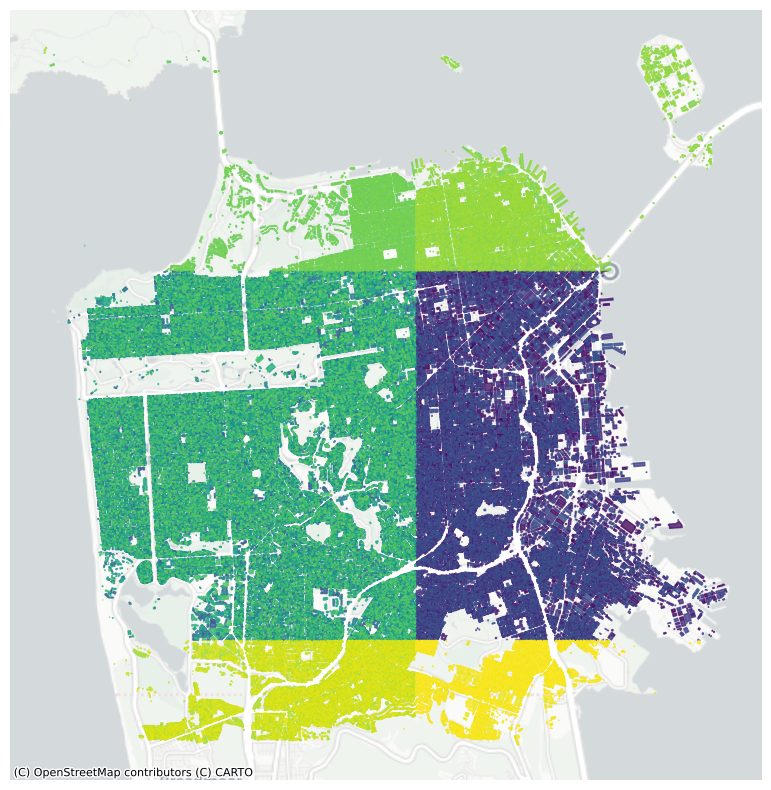

In [0]:
# Build a compact, simplified overview ONCE so it embeds interactively: tippecanoe
# drop_densest adds real low-zoom levels the gbx pyramid lacks. The full
# gbx_pmtiles_agg archive (PMTILES_PATH) stays the analysis/sharding artifact.
# Skip-guard: reuse the overview on re-runs unless FORCE_REBUILD.
if INTERACTIVE_PLOTS:
    OVERVIEW_PATH = f"{TILES_DIR}/sf_buildings_overview.pmtiles"
    if FORCE_REBUILD or not os.path.exists(OVERVIEW_PATH):
        simplify_tiles_from_source(
            buildings,
            spec={"min_z": 0, "max_z": 12, "drop_densest": True},
            geom_col="geometry",
            out_path=OVERVIEW_PATH,
        )
        print(f"... wrote {OVERVIEW_PATH} ({os.path.getsize(OVERVIEW_PATH):,} bytes)")
    else:
        print(f"... {OVERVIEW_PATH} exists (skip; FORCE_REBUILD=False)")

    # View through the INTERACTIVE_PLOTS toggle: static image (default, GitHub-renderable)
    # or an interactive MapLibre map (INTERACTIVE_PLOTS=True). emphasis="data" (default)
    # makes the buildings pop over the basemap; downzoom auto-fits to the cell budget.
    show_pmtiles(OVERVIEW_PATH)
else:
    show_pmtiles(PMTILES_PATH, emphasis="blend")

## What we built

- `overture_buildings_meta` (Delta) — the queryable asset catalog of downloaded GeoParquet.
- `sf_buildings_mvt_tiles` (Delta) — one row per `(z, x, y)` vector tile.
- `sf_buildings.pmtiles` (Volume) — a self-contained vector basemap of every candidate roof.
- A native **ST roof-area** table and an **H3 roof-density** aggregation — showing the
  tiles compose directly with Databricks-native spatial.

Next: **notebook 02** drapes NAIP aerial imagery behind these footprints as a visual basemap.